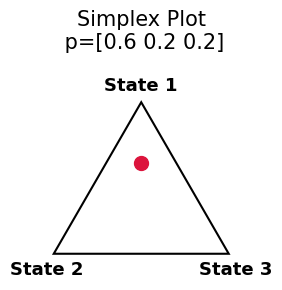

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Equilateral triangle vertices in 2D
# State 1 at top, State 2 at bottom-left, State 3 at bottom-right
vertices = np.array([
    [0.5, np.sqrt(3)/2],  # State 1 (top)
    [0.0, 0.0],           # State 2 (bottom-left)
    [1.0, 0.0],           # State 3 (bottom-right)
])

def bary_to_cart(bary, vertices):
    """Convert barycentric coordinates to Cartesian."""
    return bary @ vertices

# The point to plot
point_bary = np.array([0.6, 0.2, 0.2])
point_cart = bary_to_cart(point_bary, vertices)

fig, ax = plt.subplots(1, 1, figsize=(4, 3))

# Draw triangle
triangle = plt.Polygon(vertices, fill=False, edgecolor='black', linewidth=1.5)
ax.add_patch(triangle)

# Label vertices
offset = 0.04
ax.text(vertices[0][0], vertices[0][1] + offset, 'State 1',
        ha='center', va='bottom', fontsize=13, fontweight='bold')
ax.text(vertices[1][0] - offset, vertices[1][1] - offset, 'State 2',
        ha='center', va='top', fontsize=13, fontweight='bold')
ax.text(vertices[2][0] + offset, vertices[2][1] - offset, 'State 3',
        ha='center', va='top', fontsize=13, fontweight='bold')

# Plot the point
ax.plot(point_cart[0], point_cart[1], 'o', color='crimson', markersize=10, zorder=5)
# ax.annotate(f'({point_bary[0]}, {point_bary[1]}, {point_bary[2]})',
#             xy=(point_cart[0], point_cart[1]),
#             xytext=(point_cart[0] + 0.08, point_cart[1] + 0.05),
#             fontsize=11, color='crimson',
#             arrowprops=dict(arrowstyle='->', color='crimson', lw=1.2))

# Formatting
ax.set_xlim(-0.15, 1.15)
ax.set_ylim(-0.15, 1.05)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title(f'Simplex Plot\n p={point_bary}', fontsize=15, pad=15)

plt.tight_layout()
plt.savefig('triangle_plot_simplex.png', dpi=150, bbox_inches='tight')
plt.show()


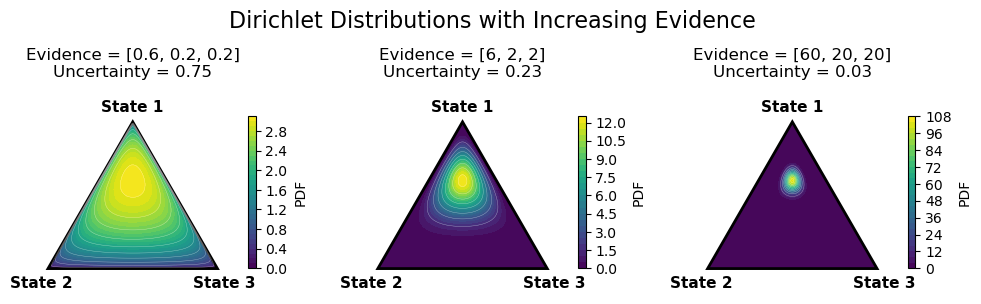

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.stats import dirichlet

# Equilateral triangle vertices in 2D
vertices = np.array([
    [0.5, np.sqrt(3)/2],  # State 1 (top)
    [0.0, 0.0],           # State 2 (bottom-left)
    [1.0, 0.0],           # State 3 (bottom-right)
])

def bary_to_cart(bary, vertices):
    return bary @ vertices

# Generate a fine grid of barycentric coordinates on the simplex
n = 100
bary_coords = []
for i in range(n + 1):
    for j in range(n + 1 - i):
        k = n - i - j
        b = np.array([i, j, k]) / n
        b = np.clip(b, 1e-6, 1.0)
        b /= b.sum()
        bary_coords.append(b)

bary_coords = np.array(bary_coords)
cart_coords = bary_to_cart(bary_coords, vertices)
triang = mtri.Triangulation(cart_coords[:, 0], cart_coords[:, 1])

# Three evidence vectors
evidence_list = [
    [0.6, 0.2, 0.2],
    [6, 2, 2],
    [60, 20, 20],
]

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for ax, evidence in zip(axes, evidence_list):
    alpha = np.array(evidence) + 1
    S = np.sum(alpha)
    belief = np.array(evidence) / S
    uncertainty = len(evidence) / S

    # Evaluate Dirichlet PDF
    pdf_vals = dirichlet.pdf(bary_coords.T, alpha)

    # Filled contour plot
    tcf = ax.tricontourf(triang, pdf_vals, levels=30, cmap='viridis')
    ax.tricontour(triang, pdf_vals, levels=10, colors='white', linewidths=0.3, alpha=0.5)

    # Triangle border
    triangle = plt.Polygon(vertices, fill=False, edgecolor='black', linewidth=2)
    ax.add_patch(triangle)

    # Label vertices
    offset = 0.04
    ax.text(vertices[0][0], vertices[0][1] + offset, 'State 1',
            ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.text(vertices[1][0] - offset, vertices[1][1] - offset, 'State 2',
            ha='center', va='top', fontsize=11, fontweight='bold')
    ax.text(vertices[2][0] + offset, vertices[2][1] - offset, 'State 3',
            ha='center', va='top', fontsize=11, fontweight='bold')

    # Colorbar
    cbar = plt.colorbar(tcf, ax=ax, shrink=0.7, pad=0.02)
    cbar.set_label('PDF', fontsize=10)

    # Formatting
    ax.set_xlim(-0.15, 1.15)
    ax.set_ylim(-0.15, 1.05)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f'Evidence = {evidence}\nUncertainty = {uncertainty:.2f}',
                 fontsize=12, pad=10)

fig.suptitle('Dirichlet Distributions with Increasing Evidence', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('dirichlet_evidence_comparison.png', dpi=150, bbox_inches='tight')
plt.show()